# Xử lý & Trực quan hóa dữ liệu Spotify

**Input:** `data/raw/spotify_hybrid_tracks.csv`

**Output:**
- `data/processed/spotify_hybrid_processed.csv`
- `data/processed/processing_summary.json`
- `data/processed/figures/` — 4 biểu đồ EDA

**Phạm vi EDA:** mô tả dataset, phân bố mood, nguồn dữ liệu, chất lượng nhãn mood

## Bước 0 — Cài thư viện & import

In [17]:
# !pip install pandas numpy scikit-learn matplotlib seaborn

import json
import re
import string
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

sns.set_theme(style="whitegrid")
FIGURE_DPI = 120

## Bước 1 — Cấu hình đường dẫn

In [18]:
ROOT = Path(".").resolve()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
FIGURES_DIR = PROCESSED_DIR / "figures"

INPUT_FILE = RAW_DIR / "spotify_hybrid_tracks.csv"
OUTPUT_FILE = PROCESSED_DIR / "spotify_hybrid_processed.csv"
SUMMARY_FILE = PROCESSED_DIR / "processing_summary.json"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input:  {INPUT_FILE}")
print(f"Output: {OUTPUT_FILE}")

Input:  C:\Users\User\Desktop\idk\ds\data\raw\spotify_hybrid_tracks.csv
Output: C:\Users\User\Desktop\idk\ds\data\processed\spotify_hybrid_processed.csv


## Bước 2 — Đọc dữ liệu raw

In [19]:
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Không tìm thấy {INPUT_FILE}")

df = pd.read_csv(INPUT_FILE)
initial_rows = len(df)
print(f"Loaded {initial_rows} tracks, {len(df.columns)} columns")
df.head()

Loaded 8668 tracks, 27 columns


,track_id,track_name,artists,artist_ids,album,release_date,popularity,duration_ms,preview_url,spotify_url,...,source_type,source_id,source_name,track_name_clean,artists_clean,data_origin,mood_label,search_query,tags,genres
0,67NAtoGMdqY6nGZ6NIEdp0,Santa Monica,BUBBLE TEA AND CIGARETTES,2UMeX51X1prCFgi51RHo9P,There's Nothing But Pleasure,2022-09-02,NaN,344697,NaN,https://open.spotify.com/track/67NAtoGMdqY6nGZ...,...,liked,liked,Liked Songs,santa monica,bubble tea and cigarettes,profile,NaN,NaN,NaN,NaN
1,6ta5yavnnEfCE4faU0jebM,Mr Blue,Catherine Feeny,2PKUc5LXsZNjqOpAZKcFgz,Hurricane Glass,2006,NaN,154600,NaN,https://open.spotify.com/track/6ta5yavnnEfCE4f...,...,liked,liked,Liked Songs,mr blue,catherine feeny,profile,NaN,NaN,NaN,NaN
2,0qWoOHqTirzo59FQ9eoECH,All I Did Was Dream of You (feat. The Marías),"beabadoobee, The Marías",35l9BRT7MXmM8bv2WDQiyB|2sSGPbdZJkaSE2AbcGOACx,All I Did Was Dream of You (feat. The Marías),2026-03-12,NaN,223788,NaN,https://open.spotify.com/track/0qWoOHqTirzo59F...,...,liked,liked,Liked Songs,all i did was dream of you feat the marías,beabadoobee the marías,profile,NaN,NaN,NaN,NaN
3,30EldS3xSf98r4S6BOf7ZP,In Your Arms,Mr.Kitty,0pWwt5vGNzezEhfAcc420Y,Ephemeral,2019-05-24,NaN,220957,NaN,https://open.spotify.com/track/30EldS3xSf98r4S...,...,liked,liked,Liked Songs,in your arms,mrkitty,profile,NaN,NaN,NaN,NaN
4,3SrSjUKxAJ6Cq1vpe1mqCZ,I Blame The World,Sasha Alex Sloan,4xnihxcoXWK3UqryOSnbw5,I Blame The World,2022-04-08,NaN,197266,NaN,https://open.spotify.com/track/3SrSjUKxAJ6Cq1v...,...,liked,liked,Liked Songs,i blame the world,sasha alex sloan,profile,NaN,NaN,NaN,NaN


## Bước 3 — Khám phá nhanh

In [20]:
print("Shape:", df.shape)
print("\nMissing values (top):")
print(df.isna().sum().sort_values(ascending=False).head(10))

if "data_origin" in df.columns:
    print("\nNguồn dữ liệu:")
    print(df["data_origin"].value_counts())

if "mood_label" in df.columns:
    print("\nMood (trước xử lý):")
    print(df["mood_label"].fillna("(missing)").value_counts())

Shape: (8668, 27)

Missing values (top):
popularity      8668
preview_url     8668
genres          8668
isrc            7477
added_at        7375
album_type      7362
track_number    7362
disc_number     7362
explicit        7362
album_id        7362
dtype: int64

Nguồn dữ liệu:
data_origin
search     7362
profile    1306
Name: count, dtype: int64

Mood (trước xử lý):
mood_label
happy        3063
sad          1844
(missing)    1306
calm         1214
energetic     592
romantic      353
stressed      296
Name: count, dtype: int64


## Bước 4 — Loại trùng & làm sạch text

In [21]:
def clean_text(text, lowercase=True, remove_punctuation=True):
    if not isinstance(text, str):
        return ""
    cleaned = text.strip()
    if lowercase:
        cleaned = cleaned.lower()
    if remove_punctuation:
        cleaned = cleaned.translate(str.maketrans("", "", string.punctuation))
    cleaned = re.sub(r"\s+", " ", cleaned)
    return cleaned.strip()

processed = df.copy()
processed = processed.drop_duplicates(subset=["track_id"], keep="first")
processed = processed.dropna(subset=["track_name", "artists"])
processed["track_name_clean"] = processed["track_name"].apply(clean_text)
processed["artists_clean"] = processed["artists"].apply(clean_text)
print(f"Sau dedup: {len(processed)} tracks")

Sau dedup: 8668 tracks


## Bước 5 — Gán mood label

In [22]:
MOOD_KEYWORDS = {
    "happy": ["happy", "joy", "excited", "fun", "cheerful", "vui", "hạnh phúc"],
    "sad": ["sad", "lonely", "depressed", "cry", "buồn", "cô đơn"],
    "calm": ["calm", "relax", "peaceful", "chill", "thư giãn", "bình yên"],
    "energetic": ["energy", "workout", "pump", "hype", "năng lượng", "tập trung"],
    "romantic": ["love", "romantic", "date", "yêu", "lãng mạn"],
    "stressed": ["stress", "anxious", "tired", "overwhelmed", "căng thẳng", "mệt"],
}

def infer_mood_label(row):
    text = " ".join([
        str(row.get("source_name", "") or ""),
        str(row.get("search_query", "") or ""),
        str(row.get("tags", "") or ""),
        str(row.get("track_name", "") or ""),
    ]).lower()
    if not text.strip():
        return None
    scores = {m: sum(1 for kw in kws if kw in text) for m, kws in MOOD_KEYWORDS.items()}
    best_mood, best_score = max(scores.items(), key=lambda x: x[1])
    return best_mood if best_score > 0 else None

if "mood_label" not in processed.columns:
    processed["mood_label"] = None
missing_mask = processed["mood_label"].isna() | (processed["mood_label"].astype(str).str.strip() == "")
processed["mood_inferred"] = False
inferred_count = 0
for idx in processed.index[missing_mask]:
    mood = infer_mood_label(processed.loc[idx].to_dict())
    if mood:
        processed.at[idx, "mood_label"] = mood
        processed.at[idx, "mood_inferred"] = True
        inferred_count += 1
still_missing = processed["mood_label"].isna() | (processed["mood_label"].astype(str).str.strip() == "")
processed.loc[still_missing, "mood_label"] = "calm"
print(f"Suy luận mood: {inferred_count} track")
print(processed["mood_label"].value_counts())

Suy luận mood: 172 track
mood_label
happy        3065
calm         2365
sad          1859
energetic     592
romantic      491
stressed      296
Name: count, dtype: int64


## Bước 6 — Chuẩn hóa metadata

In [23]:
def first_artist(value):
    return value.split(",")[0].strip() if isinstance(value, str) and value.strip() else ""

def split_tags(value):
    if not isinstance(value, str) or not value.strip():
        return []
    return [p.strip().lower() for p in value.split(",") if p.strip()]

processed["primary_artist"] = processed["artists"].apply(first_artist)
processed["release_year"] = pd.to_datetime(processed["release_date"], errors="coerce").dt.year
processed["duration_min"] = (processed["duration_ms"] / 60_000).round(2)
processed["explicit"] = processed["explicit"].fillna(False).astype(bool)
if "tags" in processed.columns:
    processed["tags_list"] = processed["tags"].apply(split_tags)
    processed["tags_normalized"] = processed["tags_list"].apply(lambda p: ", ".join(p) if p else "")
processed.head()

,track_id,track_name,artists,artist_ids,album,release_date,popularity,duration_ms,preview_url,spotify_url,...,mood_label,search_query,tags,genres,mood_inferred,primary_artist,release_year,duration_min,tags_list,tags_normalized
0,67NAtoGMdqY6nGZ6NIEdp0,Santa Monica,BUBBLE TEA AND CIGARETTES,2UMeX51X1prCFgi51RHo9P,There's Nothing But Pleasure,2022-09-02,NaN,344697,NaN,https://open.spotify.com/track/67NAtoGMdqY6nGZ...,...,calm,NaN,NaN,NaN,False,BUBBLE TEA AND CIGARETTES,2022.0,5.74,[],
1,6ta5yavnnEfCE4faU0jebM,Mr Blue,Catherine Feeny,2PKUc5LXsZNjqOpAZKcFgz,Hurricane Glass,2006,NaN,154600,NaN,https://open.spotify.com/track/6ta5yavnnEfCE4f...,...,calm,NaN,NaN,NaN,False,Catherine Feeny,NaN,2.58,[],
2,0qWoOHqTirzo59FQ9eoECH,All I Did Was Dream of You (feat. The Marías),"beabadoobee, The Marías",35l9BRT7MXmM8bv2WDQiyB|2sSGPbdZJkaSE2AbcGOACx,All I Did Was Dream of You (feat. The Marías),2026-03-12,NaN,223788,NaN,https://open.spotify.com/track/0qWoOHqTirzo59F...,...,calm,NaN,NaN,NaN,False,beabadoobee,2026.0,3.73,[],
3,30EldS3xSf98r4S6BOf7ZP,In Your Arms,Mr.Kitty,0pWwt5vGNzezEhfAcc420Y,Ephemeral,2019-05-24,NaN,220957,NaN,https://open.spotify.com/track/30EldS3xSf98r4S...,...,calm,NaN,NaN,NaN,False,Mr.Kitty,2019.0,3.68,[],
4,3SrSjUKxAJ6Cq1vpe1mqCZ,I Blame The World,Sasha Alex Sloan,4xnihxcoXWK3UqryOSnbw5,I Blame The World,2022-04-08,NaN,197266,NaN,https://open.spotify.com/track/3SrSjUKxAJ6Cq1v...,...,calm,NaN,NaN,NaN,False,Sasha Alex Sloan,2022.0,3.29,[],


## Bước 7 — Tạo text features

In [24]:
stopwords = set(ENGLISH_STOP_WORDS)

def build_combined_text(row):
    parts = [
        row.get("track_name_clean") or row.get("track_name", ""),
        row.get("artists_clean") or row.get("artists", ""),
        row.get("tags_normalized") or row.get("tags", ""),
        row.get("search_query", ""),
        row.get("source_name", ""),
    ]
    return " ".join(p for p in (clean_text(str(x)) for x in parts if x) if p)

def tokenize(text):
    return [t for t in text.split() if t not in stopwords and len(t) > 1] if text else []

text_features = processed.apply(
    lambda row: pd.Series({
        "combined_text": (ct := build_combined_text(row.to_dict())),
        "tokens": " ".join(tokens := tokenize(ct)),
        "token_count": len(tokens),
    }),
    axis=1,
)
processed = pd.concat([processed, text_features], axis=1)
for col, default in [("tags", ""), ("tags_normalized", ""), ("search_query", ""), ("combined_text", ""), ("tokens", "")]:
    if col in processed.columns:
        processed[col] = processed[col].fillna(default)
processed["token_count"] = processed["token_count"].fillna(0).astype(int)
if "data_origin" in processed.columns:
    processed["data_origin"] = processed["data_origin"].fillna("unknown")

## Bước 8 — Lưu dữ liệu đã xử lý

In [25]:
summary = {
    "initial_rows": initial_rows,
    "final_rows": len(processed),
    "duplicates_removed": initial_rows - len(processed),
    "mood_labels_inferred": inferred_count,
    "mood_distribution": processed["mood_label"].value_counts().to_dict(),
}
processed.to_csv(OUTPUT_FILE, index=False)
SUMMARY_FILE.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Saved {OUTPUT_FILE} ({len(processed)} tracks)")

Saved C:\Users\User\Desktop\idk\ds\data\processed\spotify_hybrid_processed.csv (8668 tracks)


## Bước 9 — Trực quan hóa

1. **Phân bố mood** (+ % class imbalance)
2. **Nguồn dữ liệu** — profile vs search
3. **Mood × nguồn** — heatmap
4. **Chất lượng nhãn mood** — search query vs suy luận vs mặc định

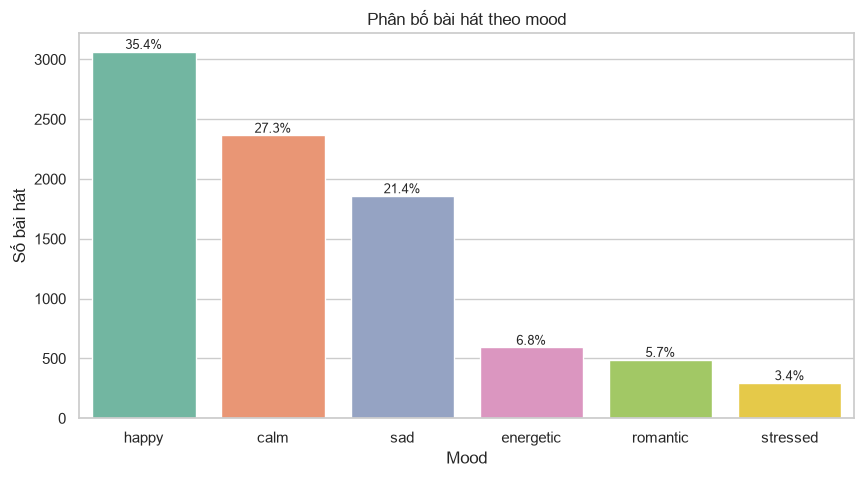

     mood  count  pct
    happy   3065 35.4
     calm   2365 27.3
      sad   1859 21.4
energetic    592  6.8
 romantic    491  5.7
 stressed    296  3.4


In [26]:
# 1. Phân bố mood (+ %)
mood_counts = processed["mood_label"].value_counts().reset_index()
mood_counts.columns = ["mood", "count"]
mood_counts["pct"] = (mood_counts["count"] / mood_counts["count"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=mood_counts, x="mood", y="count", hue="mood", palette="Set2", ax=ax, legend=False)
for i, row in mood_counts.iterrows():
    ax.text(i, row["count"], f"{row['pct']}%", ha="center", va="bottom", fontsize=9)
ax.set_title("Phân bố bài hát theo mood")
ax.set_xlabel("Mood")
ax.set_ylabel("Số bài hát")
fig.savefig(FIGURES_DIR / "01_mood_distribution.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

print(mood_counts.to_string(index=False))

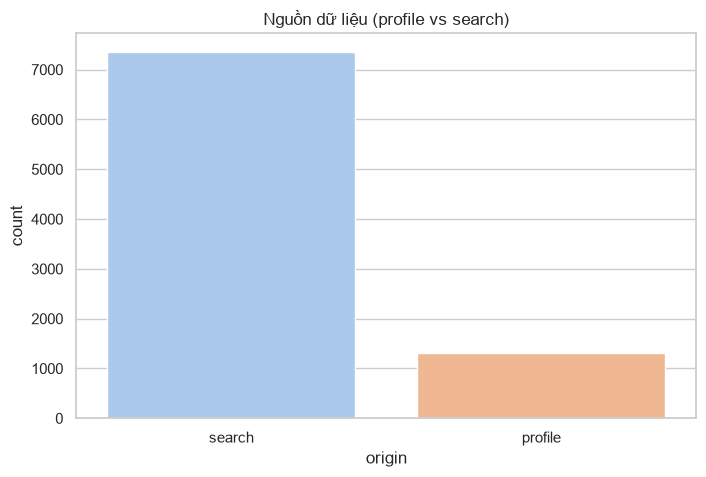

In [27]:
# 2. Nguồn dữ liệu
if "data_origin" in processed.columns:
    origin_counts = processed["data_origin"].value_counts().reset_index()
    origin_counts.columns = ["origin", "count"]

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=origin_counts, x="origin", y="count", hue="origin", palette="pastel", ax=ax, legend=False)
    ax.set_title("Nguồn dữ liệu (profile vs search)")
    fig.savefig(FIGURES_DIR / "02_data_origin.png", dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

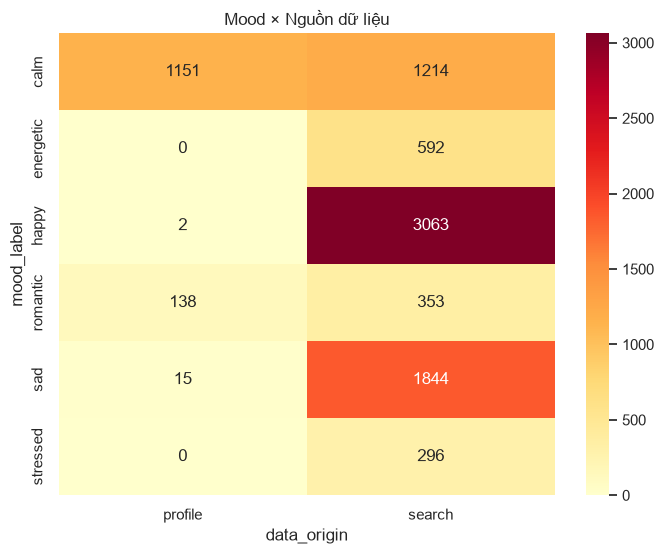

Đã lưu biểu đồ vào C:\Users\User\Desktop\idk\ds\data\processed\figures


In [28]:
# 3. Mood × nguồn dữ liệu
if "data_origin" in processed.columns:
    pivot = pd.crosstab(processed["mood_label"], processed["data_origin"])
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
    ax.set_title("Mood × Nguồn dữ liệu")
    fig.savefig(FIGURES_DIR / "03_mood_origin_heatmap.png", dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

print(f"Đã lưu biểu đồ vào {FIGURES_DIR}")

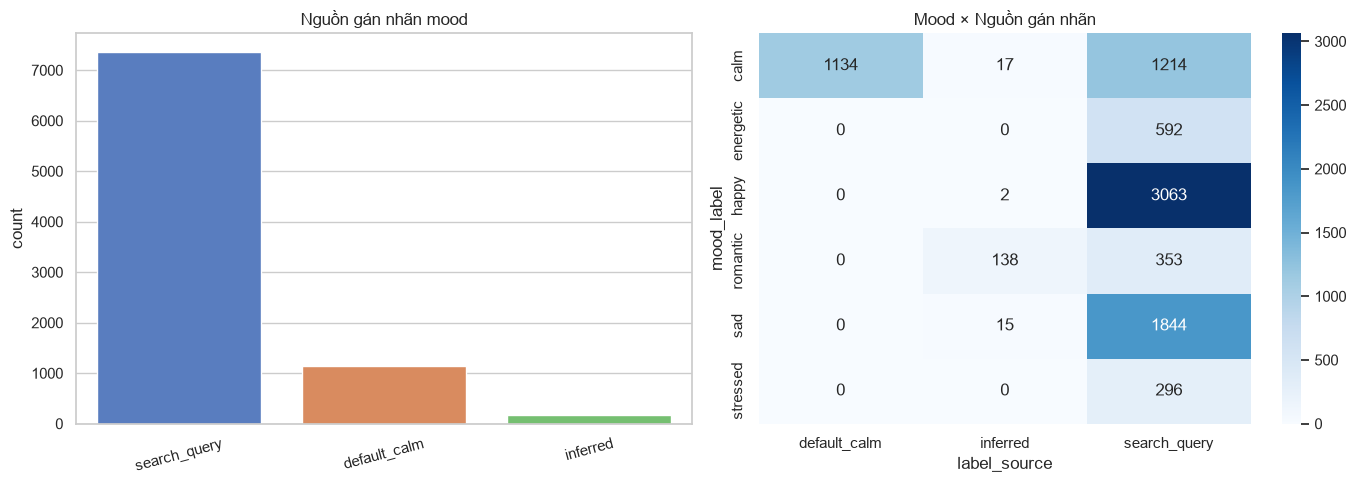

      source  count
search_query   7362
default_calm   1134
    inferred    172


In [29]:
# 4. Chất lượng nhãn mood
def label_source(row):
    if row.get("data_origin") == "search":
        return "search_query"
    if row.get("mood_inferred"):
        return "inferred"
    return "default_calm"

processed["label_source"] = processed.apply(label_source, axis=1)

label_counts = processed["label_source"].value_counts().reset_index()
label_counts.columns = ["source", "count"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=label_counts, x="source", y="count", hue="source", palette="muted", ax=axes[0], legend=False)
axes[0].set_title("Nguồn gán nhãn mood")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=15)

label_by_mood = pd.crosstab(processed["mood_label"], processed["label_source"])
sns.heatmap(label_by_mood, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Mood × Nguồn gán nhãn")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_label_quality.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

print(label_counts.to_string(index=False))